What exactly is in the dataset we want to see?

In [2]:
from pathlib import Path

DATA_ROOT = Path("../data/raw/JPEGImages")

print(DATA_ROOT.resolve())

for path in DATA_ROOT.rglob("*"):
    print(path)
    

G:\VSrepos\repos\cellvision\data\raw\JPEGImages
..\data\raw\JPEGImages\BloodImage_00000.jpg
..\data\raw\JPEGImages\BloodImage_00001.jpg
..\data\raw\JPEGImages\BloodImage_00002.jpg
..\data\raw\JPEGImages\BloodImage_00003.jpg
..\data\raw\JPEGImages\BloodImage_00004.jpg
..\data\raw\JPEGImages\BloodImage_00005.jpg
..\data\raw\JPEGImages\BloodImage_00006.jpg
..\data\raw\JPEGImages\BloodImage_00007.jpg
..\data\raw\JPEGImages\BloodImage_00008.jpg
..\data\raw\JPEGImages\BloodImage_00009.jpg
..\data\raw\JPEGImages\BloodImage_00010.jpg
..\data\raw\JPEGImages\BloodImage_00011.jpg
..\data\raw\JPEGImages\BloodImage_00012.jpg
..\data\raw\JPEGImages\BloodImage_00013.jpg
..\data\raw\JPEGImages\BloodImage_00014.jpg
..\data\raw\JPEGImages\BloodImage_00015.jpg
..\data\raw\JPEGImages\BloodImage_00016.jpg
..\data\raw\JPEGImages\BloodImage_00017.jpg
..\data\raw\JPEGImages\BloodImage_00018.jpg
..\data\raw\JPEGImages\BloodImage_00019.jpg
..\data\raw\JPEGImages\BloodImage_00020.jpg
..\data\raw\JPEGImages\Blood

In [3]:

from pathlib import Path

image_extensions = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp"
}

images = [
    path
    for path in DATA_ROOT.rglob("*")
    if path.suffix.lower() in image_extensions
]

print(f"Total Images: {len(images)}")


Total Images: 364


Now we want to normaize image dimensions

In [4]:
from PIL import Image
from collections import Counter

dimensions = []

for image_path in images:
    try:
        with Image.open(image_path) as img:
            dimensions.append(img.size)
    except Exception as e:
        print(f"Could not read {image_path}: {e}")

dimension_counts = Counter(dimensions)

dimension_counts.most_common(10)


[((640, 480), 364)]

Detecting corrupt or invalid images.

In [5]:
invalid_images = []
for image_path in images:
    try:
        with Image.open(image_path) as img:
            img.verify()
    except Exception:
        invalid_images.append(image_path)

print(f"Invalid images: {len(invalid_images)}")

Invalid images: 0


We want to visualize Data sample images. 

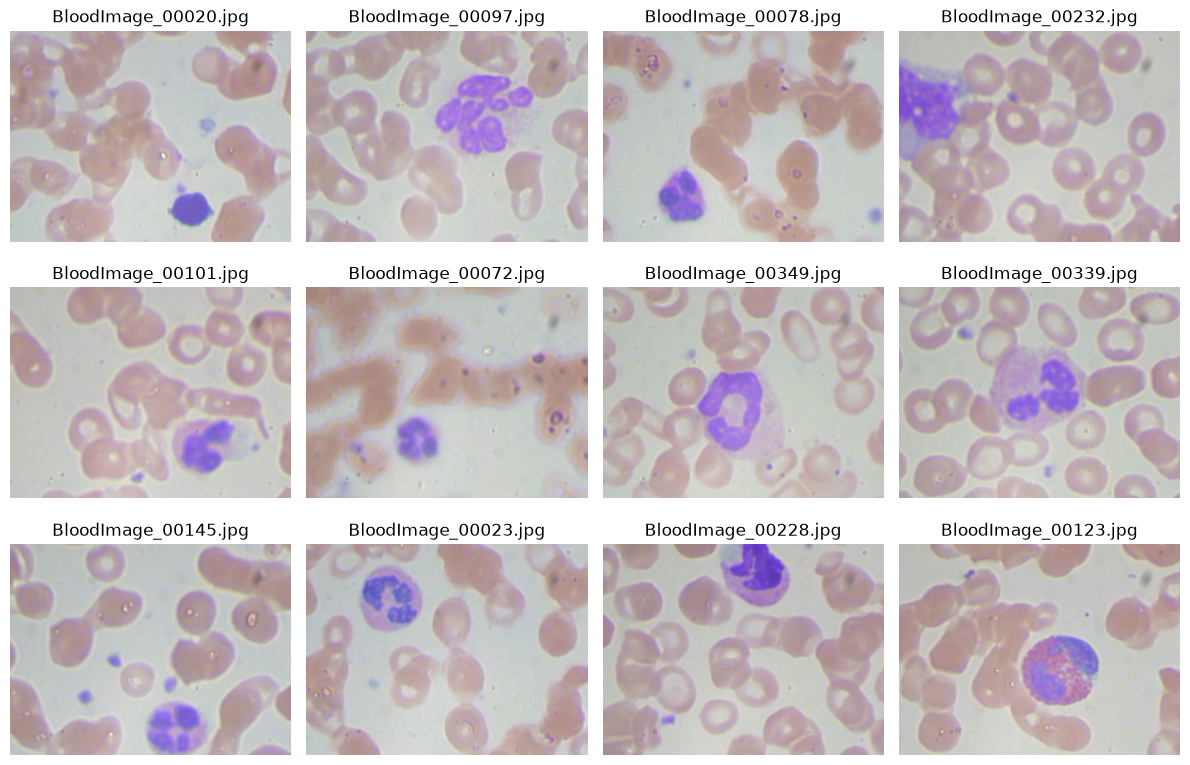

In [6]:
import matplotlib.pyplot as plt
import random
from PIL import Image


sample_images = random.sample(images, min(12, len(images)))

plt.figure(figsize=(12, 8))

for i, image_path in enumerate(sample_images):
    image = Image.open(image_path)

    plt.subplot(3, 4, i + 1)
    plt.imshow(image)
    plt.axis("off")
    plt.title(image_path.name)

plt.tight_layout()
plt.show()

Annotations to get determination of dataset representations.
class: RBC
x: 120
y: 80
width: 35
height: 35

Ending View is similar to below:

CellVision Dataset Report
────────────────────────────

Dataset:
BCCD

Images:
XXXX

Readable:
XXXX

Corrupt:
0

Image dimensions:
640 × 480: XXXX
...

Annotations:
XXXX

Classes:
RBC
WBC
Platelet

Objects:
RBC:       XXXX
WBC:        XXX
Platelet:   XXX

In [7]:
annotation_extensions = {
    ".xml",
    ".json",
    ".txt",
    ".csv"
}

DATA_ROOT = Path("../data/raw/Annotations")
annotations = [
    path
    for path in DATA_ROOT.rglob("*")
    if path.is_file() and path.suffix.lower() in annotation_extensions
]

print(f"Potential annotation files: {len(annotations)}")

for annotation in annotations[:20]:
    print(annotation)

Potential annotation files: 364
..\data\raw\Annotations\BloodImage_00000.xml
..\data\raw\Annotations\BloodImage_00001.xml
..\data\raw\Annotations\BloodImage_00002.xml
..\data\raw\Annotations\BloodImage_00003.xml
..\data\raw\Annotations\BloodImage_00004.xml
..\data\raw\Annotations\BloodImage_00005.xml
..\data\raw\Annotations\BloodImage_00006.xml
..\data\raw\Annotations\BloodImage_00007.xml
..\data\raw\Annotations\BloodImage_00008.xml
..\data\raw\Annotations\BloodImage_00009.xml
..\data\raw\Annotations\BloodImage_00010.xml
..\data\raw\Annotations\BloodImage_00011.xml
..\data\raw\Annotations\BloodImage_00012.xml
..\data\raw\Annotations\BloodImage_00013.xml
..\data\raw\Annotations\BloodImage_00014.xml
..\data\raw\Annotations\BloodImage_00015.xml
..\data\raw\Annotations\BloodImage_00016.xml
..\data\raw\Annotations\BloodImage_00017.xml
..\data\raw\Annotations\BloodImage_00018.xml
..\data\raw\Annotations\BloodImage_00019.xml


Testing an annotaion. 

In [8]:
import sys 
import os
from pathlib import Path
PROJECT_ROOT = Path("..").resolve()

sys.path.append(str(PROJECT_ROOT))

from src.data.parse_annotations import parse_annotation

annotation_path = annotations[0]

records = parse_annotation(annotation_path)
print(records)


[{'filename': 'BloodImage_00000.jpg', 'width': 640, 'height': 480, 'class': 'WBC', 'xmin': 260, 'ymin': 177, 'xmax': 491, 'ymax': 376}, {'filename': 'BloodImage_00000.jpg', 'width': 640, 'height': 480, 'class': 'RBC', 'xmin': 78, 'ymin': 336, 'xmax': 184, 'ymax': 435}, {'filename': 'BloodImage_00000.jpg', 'width': 640, 'height': 480, 'class': 'RBC', 'xmin': 63, 'ymin': 237, 'xmax': 169, 'ymax': 336}, {'filename': 'BloodImage_00000.jpg', 'width': 640, 'height': 480, 'class': 'RBC', 'xmin': 214, 'ymin': 362, 'xmax': 320, 'ymax': 461}, {'filename': 'BloodImage_00000.jpg', 'width': 640, 'height': 480, 'class': 'RBC', 'xmin': 414, 'ymin': 352, 'xmax': 506, 'ymax': 445}, {'filename': 'BloodImage_00000.jpg', 'width': 640, 'height': 480, 'class': 'RBC', 'xmin': 555, 'ymin': 356, 'xmax': 640, 'ymax': 455}, {'filename': 'BloodImage_00000.jpg', 'width': 640, 'height': 480, 'class': 'RBC', 'xmin': 469, 'ymin': 412, 'xmax': 567, 'ymax': 480}, {'filename': 'BloodImage_00000.jpg', 'width': 640, 'heig

If there is a reason we get a list out of range is that there is no XML parses from the previous set of extensions, because none exist. Only run when annotations are found and added to dataset. 

In [9]:
import pandas as pd

all_records = []

for annotation_path in annotations:
    try:
        records = parse_annotation(annotation_path)
        all_records.extend(records)
    except Exception as e:
        print(f"Failed to parse {annotation_path}: {e}")

annotations_df = pd.DataFrame(all_records)
annotations_df.head()


,filename,width,height,class,xmin,ymin,xmax,ymax
0,BloodImage_00000.jpg,640,480,WBC,260,177,491,376
1,BloodImage_00000.jpg,640,480,RBC,78,336,184,435
2,BloodImage_00000.jpg,640,480,RBC,63,237,169,336
3,BloodImage_00000.jpg,640,480,RBC,214,362,320,461
4,BloodImage_00000.jpg,640,480,RBC,414,352,506,445


Determine Classes of the dataframe.

In [10]:
annotations_df["class"].value_counts()

class
RBC          4155
WBC           372
Platelets     361
Name: count, dtype: int64

Visuazlizing the class imbalances.

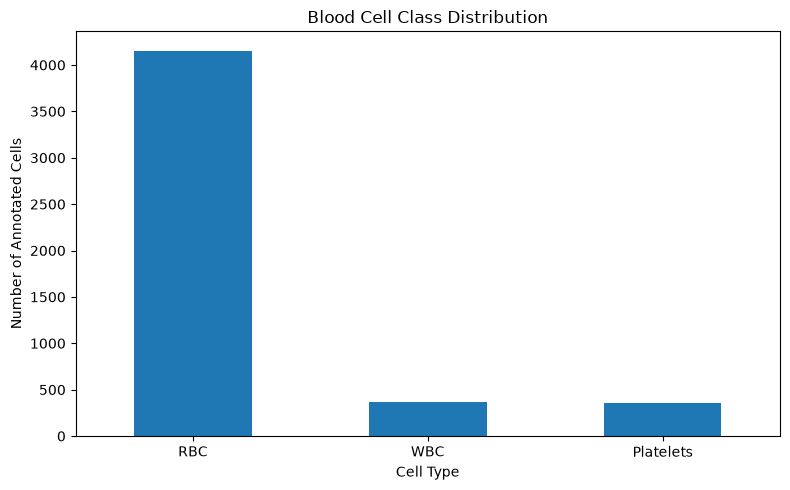

In [11]:
class_counts = annotations_df["class"].value_counts()

class_counts.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Blood Cell Class Distribution")
plt.xlabel("Cell Type")
plt.ylabel("Number of Annotated Cells")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


Check for missing values of all the set and validate the bounding boxes

In [12]:
annotations_df.isnull().sum()

def validate_bbox(row):
    return(
        row["xmin"] >= 0
        and row["ymin"] >= 0
        and row["xmax"] <= row["width"]
        and row["ymax"] <= row["height"]
        and row["xmin"] < row["xmax"]
        and row["ymin"] < row["ymax"]
    )

annotations_df["bbox_valid"] = annotations_df.apply(
    validate_bbox,
    axis=1
)

annotations_df["bbox_valid"].value_counts()


bbox_valid
True     4886
False       2
Name: count, dtype: int64

Find the invalid bounding boxes

In [13]:
invalid_boxes = annotations_df[
    ~annotations_df["bbox_valid"]
]

print(invalid_boxes)


                  filename  width  height class  xmin  ymin  xmax  ymax  \
3950  BloodImage_00338.jpg    640     480   RBC   504   337   504   337   
4004  BloodImage_00343.jpg    640     480   RBC   181   329   181   329   

      bbox_valid  
3950       False  
4004       False  


Calculate the cell dimension

In [14]:
annotations_df["box_width"] = (
    annotations_df["xmax"] - annotations_df["xmin"]
)

annotations_df["box_height"] = (
    annotations_df["ymax"] - annotations_df["ymin"]
)

annotations_df["box_area"] = (
    annotations_df["box_width"] * annotations_df["box_height"]
)

annotations_df["aspect_ratio"] = (
    annotations_df["box_width"] / annotations_df["box_height"]
)

annotations_df[
    [
        "class",
        "box_width",
        "box_height",
        "box_area",
        "aspect_ratio"
    ]
].describe()

,box_width,box_height,box_area,aspect_ratio
count,4888.000000,4888.000000,4888.000000,4886.000000
mean,106.604951,101.625818,11768.211538,1.065181
std,35.403703,31.899194,8502.441881,0.213485
min,0.000000,0.000000,0.000000,0.333333
25%,93.000000,90.000000,8666.250000,0.949183
50%,105.000000,101.000000,10400.000000,1.042105
75%,116.000000,111.000000,12321.000000,1.152009
max,338.000000,286.000000,84838.000000,2.704762


Looking for suspisious annotaitons, such as extememly small and large bounding boxes.

In [15]:
annotations_df.sort_values(
    "box_area"
).head(20)

annotations_df.sort_values(
    "box_area",
    ascending=False
).head(20)

,filename,width,height,class,xmin,ymin,xmax,ymax,bbox_valid,box_width,box_height,box_area,aspect_ratio
4132,BloodImage_00352.jpg,640,480,WBC,294,181,632,432,True,338,251,84838,1.346614
3377,BloodImage_00284.jpg,640,480,WBC,216,209,517,480,True,301,271,81571,1.110701
4538,BloodImage_00383.jpg,640,480,WBC,225,217,531,480,True,306,263,80478,1.163498
4000,BloodImage_00342.jpg,640,480,WBC,111,106,420,362,True,309,256,79104,1.207031
3800,BloodImage_00323.jpg,640,480,WBC,22,120,330,360,True,308,240,73920,1.283333
3070,BloodImage_00255.jpg,640,480,WBC,283,42,551,294,True,268,252,67536,1.063492
163,BloodImage_00009.jpg,640,480,WBC,23,137,255,423,True,232,286,66352,0.811189
4026,BloodImage_00344.jpg,640,480,WBC,74,108,336,359,True,262,251,65762,1.043825
4655,BloodImage_00392.jpg,640,480,WBC,128,67,410,296,True,282,229,64578,1.231441
4146,BloodImage_00353.jpg,640,480,WBC,262,191,518,436,True,256,245,62720,1.044898


Verifying annnotations that have corresponding images.

In [16]:
image_lookup = {
    image.name: image
    for image in images
}

annotations_df["image_exists"] = (
    annotations_df["filename"].isin(image_lookup)
)

annotations_df["image_exists"].value_counts()


image_exists
True    4888
Name: count, dtype: int64

Finding images without annotations.

In [17]:
annotated_images = set(
    annotations_df["filename"]
)

unannotated_images = [
    image
    for image in images
    if image.name not in annotated_images
]

print(
    f"Images without annotations: "
    f"{len(unannotated_images)}"
)

Images without annotations: 0


Generating a dataset-level summary.

In [18]:
summary = {
    "total_images": len(images),
    "total_annotations": len(annotations_df),
    "invalid_images": len(invalid_images),
    "invalid_bboxes": int(
        (~annotations_df["bbox_valid"]).sum()
    ),
    "classes": annotations_df["class"].nunique(),

}

print(summary)


{'total_images': 364, 'total_annotations': 4888, 'invalid_images': 0, 'invalid_bboxes': 2, 'classes': 3}


Visualize bounding boxes as we dont want to trust one annotation file when it parses correctly.

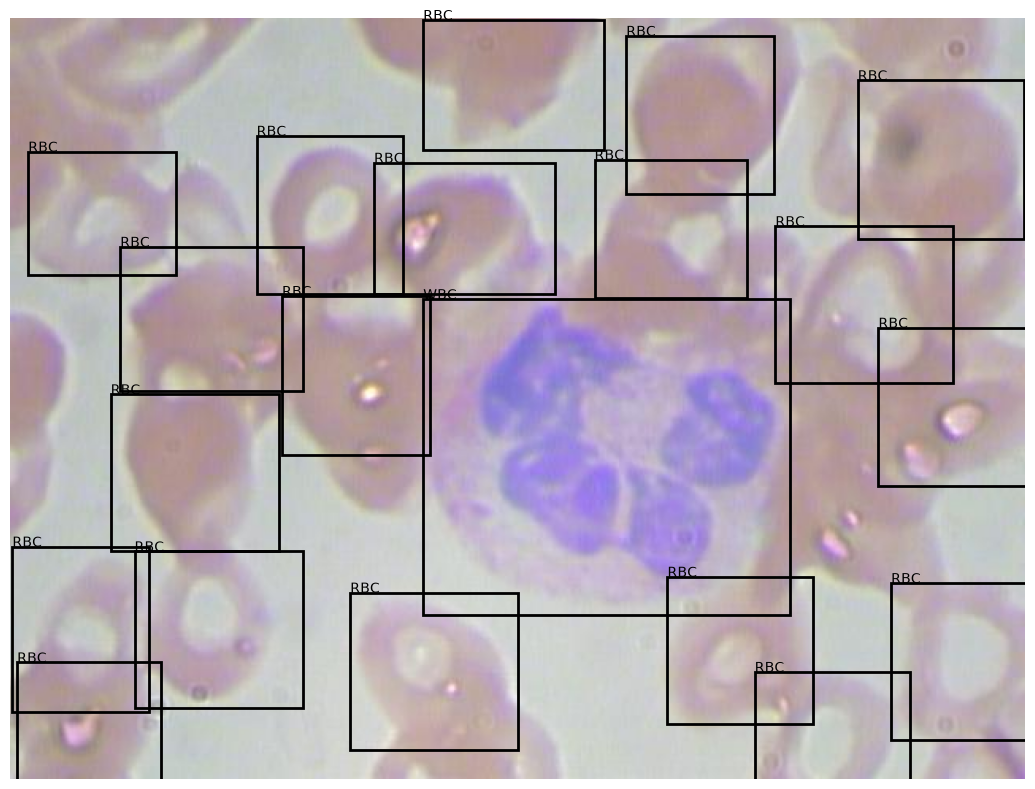

In [19]:
import matplotlib.patches as patches

sample_filename = annotations_df["filename"].iloc[0]
sample_image_path = image_lookup[sample_filename]
image = Image.open(sample_image_path)
fig, ax = plt.subplots(figsize=(12, 8))

ax.imshow(image)

sample_annotations= annotations_df[
    annotations_df["filename"] == sample_filename
]

for _, row in sample_annotations.iterrows():
    rectangle = patches.Rectangle(
        (
            row["xmin"],
            row["ymin"]
        ),
        row["box_width"],
        row["box_height"],
        fill=False,
        linewidth=2
    )

    ax.add_patch(rectangle)

    ax.text(
        row["xmin"],
        row["ymin"],
        row["class"]
    )
ax.axis("off")
plt.tight_layout()
plt.show()



Save Dataset

In [20]:
processed_dir = PROJECT_ROOT / "data" / "processed"
processed_dir.mkdir(
    parents=True,
    exist_ok=True
)

annotations_df.to_csv(
    processed_dir / "annotations.csv",
    index=False
)

print(
    f"Saved to: "
    f"{processed_dir / 'annotations.csv'}"
)

Saved to: G:\VSrepos\repos\cellvision\data\processed\annotations.csv


In [21]:
annotations_df["image_id"] = (
    annotations_df["filename"]
    .str.extract(r"(\d+)")
    .astype("Int64")
)

annotations_df[
    ["filename", "image_id"]
].head(20)



,filename,image_id
0,BloodImage_00000.jpg,0
1,BloodImage_00000.jpg,0
2,BloodImage_00000.jpg,0
3,BloodImage_00000.jpg,0
4,BloodImage_00000.jpg,0
5,BloodImage_00000.jpg,0
6,BloodImage_00000.jpg,0
7,BloodImage_00000.jpg,0
8,BloodImage_00000.jpg,0
9,BloodImage_00000.jpg,0


Building an image-level dataset for splitting.

In [22]:
image_df = (
    annotations_df[
        ["filename", "image_id"]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

image_df.head()

print(f"Unique images: {len(image_df)}")

print(f"Image File: {len(images)}")


Unique images: 364
Image File: 364


Looking for images without annotations, with images to be verified annotations. 

In [23]:
annotated_filenames = set(
    annotations_df["filename"]
)

all_image_df = pd.DataFrame({
    "filename": [
        image.name 
        for image in images
    ]
})

all_image_df["has_annotation"] = (
    all_image_df["filename"].isin(
        annotated_filenames
    )
)

all_image_df["has_annotation"].value_counts()


has_annotation
True    364
Name: count, dtype: int64

Initializing Random Seed to reproduce experiments.
Initializing split. 

In [27]:
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

train_df, temp_df = train_test_split(
    image_df,
    test_size=0.30,
    random_state=RANDOM_SEED,
    shuffle=True
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=RANDOM_SEED,
    shuffle=True
)

print(f"Training: {len(train_df)}")
print(f"Validation: {len(val_df)}")
print(f"Testing: {len(test_df)}")

total = len(train_df) + len(val_df) + len(test_df)

if total == len(image_df):
    print(f"Total: {total}")    
    print(f"Image df is: {len(image_df)}")
else:
    print(f"The images_df and total are not the same.")




Training: 254
Validation: 55
Testing: 55
Total: 364
Image df is: 364


Verifying there is no overlap in the testing. 

In [34]:
train_images = set(train_df["filename"])
val_images = set(val_df["filename"])
test_images = set(test_df["filename"])

if len(train_images & val_images) == len(train_images & test_images) == len(val_images & test_images) == 0:
    print("Train n Validation:", len(train_images & val_images)) 
    print("Train n Test:", len(train_images & test_images)) 
    print("Validation n Test:", len(val_images & test_images)) 
else:
    print(f"Error in the splitting.")


combined = (
    train_images | 
    val_images | 
    test_images
)

print("Unique split images:", len(combined))
print("Original images:", len(image_df))


Train n Validation: 0
Train n Test: 0
Validation n Test: 0
Unique split images: 364
Original images: 364


Assigning Split label into one manifest

In [35]:
train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()

train_df["split"] = "train"
val_df["split"] = "val"
test_df["split"] = "test"

split_df = pd.concat(
    [
        train_df, 
        val_df,
        test_df
    ], 
    ignore_index=True
)

split_df.head()

,filename,image_id,split
0,BloodImage_00302.jpg,302,train
1,BloodImage_00264.jpg,264,train
2,BloodImage_00183.jpg,183,train
3,BloodImage_00019.jpg,19,train
4,BloodImage_00171.jpg,171,train


Checking the split distribution

In [36]:
split_df["split"].value_counts()
split_df["split"].value_counts(
    normalize=True
)

split
train    0.697802
val      0.151099
test     0.151099
Name: proportion, dtype: float64

Investigate class distribution by split

In [37]:
annotation_splits = annotations_df.merge(
    split_df[
        ["filename", "split"]
    ],
    on="filename",
    how="left"
)

annotation_splits[
    ["filename", "class", "split"]
].head()

class_by_split = pd.crosstab(
    annotation_splits["split"],
    annotation_splits["class"]
)

print(class_by_split)

class  Platelets   RBC  WBC
split                      
test          73   629   53
train        227  2857  262
val           61   669   57


Visualize Class Distribution

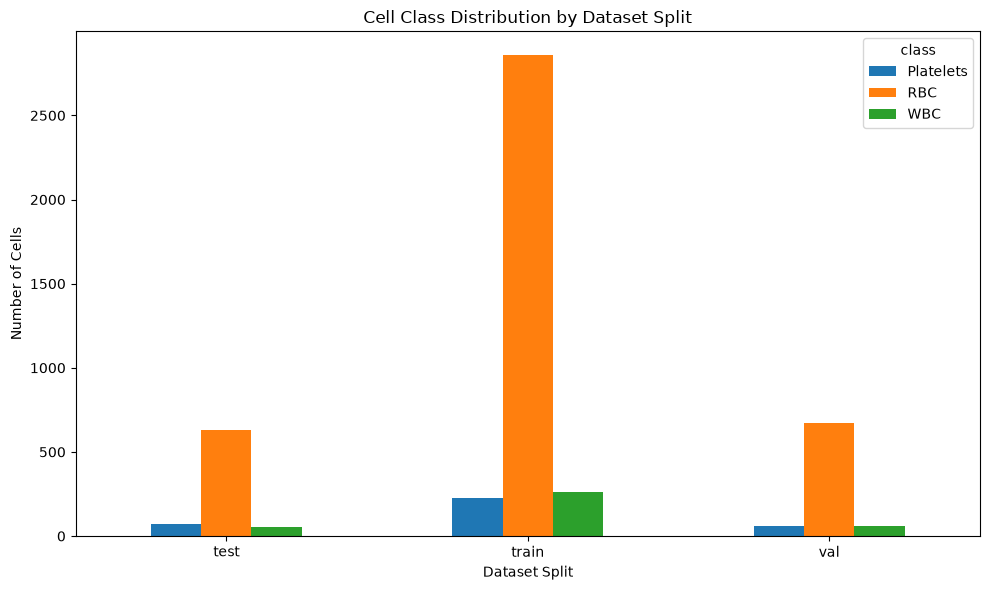

In [38]:
class_by_split.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Cell Class Distribution by Dataset Split")

plt.xlabel("Dataset Split")
plt.ylabel("Number of Cells")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

Save the split manifest

In [39]:
split_dir = (PROJECT_ROOT / "data" / "splits")

split_dir.mkdir(parents=True, exist_ok=True)

split_df.to_csv(split_dir / "dataset_split.csv", index=False)


Dataset Version along with YOLO Directory structure.

In [40]:
from pathlib import Path

DATASET_VERSION = "v1"

split_df["dataset_version"] = DATASET_VERSION

yolo_root = (PROJECT_ROOT / "data" / "processed" / "yolo")

for split in ["train", "val", "test"]:
    (yolo_root / split / "images").mkdir(
        parents=True,
        exist_ok=True
    )

    (yolo_root / split / "labels").mkdir(
        parents=True,
        exist_ok=True
    )

    